In [1]:
import sys
import os

sys.path.append("..")
sys.path.append("../..")
sys.path.append("../../..")

In [2]:
os.makedirs("./logs/", exist_ok=True)
os.makedirs("./figs/env/", exist_ok=True)
os.makedirs("./figs/exp/", exist_ok=True)

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt  
import seaborn as sns

from tqdm import tqdm

from experiment.utils.utils import logit

from typing import Literal

sns.set_palette("hls")

In [4]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [ ]:
import hydra
from hydra import initialize, compose
from hydra.core.global_hydra import GlobalHydra


GlobalHydra.instance().clear()
initialize(version_base=None, config_path="../../config")

config = compose(config_name="config")

print(config)

## criteo attr data processing

In [5]:
CSV_FILE = "./bidding_predictions.csv"

In [6]:
DF = pd.read_csv(CSV_FILE).sort_values("timestamp").reset_index(drop=True)

CAMPAIGN_IDS = sorted(DF["campaign"].unique())

In [7]:
print(f"camp_count = {len(CAMPAIGN_IDS)}", f"avg_auctions_per_camp = {len(DF) / len(CAMPAIGN_IDS):.2f}", f"clicks = {DF['click'].sum()}", f"conversions = {DF['conversion'].sum()}", sep="\n")

camp_count = 669
avg_auctions_per_camp = 4923.18
clicks = 1210554
conversions = 158921


In [8]:
campaign_stats = DF.groupby("campaign").agg(
    n_auctions=("campaign", "count"),
    n_conversions=("conversion", "sum")
)

valid_ids = campaign_stats[
    (campaign_stats["n_conversions"] >= 10) & 
    (campaign_stats["n_auctions"] >= 500)
].index

DF_FILTERED = DF[DF["campaign"].isin(valid_ids)].copy()
CAMPAIGN_IDS_FILTERED = sorted(DF_FILTERED["campaign"].unique())
len(CAMPAIGN_IDS_FILTERED)

560

In [9]:
def sample_campaign(
    campaign_id,
    models_mode,
    df = DF_FILTERED,
):
    campaign_df = df[df["campaign"] == campaign_id].copy().reset_index(drop=True)

    columns = {
        "ctr_noised_lgt": f"{models_mode}_ctr_pred_logit",
        "ctr_lgt_sigma": f"{models_mode}_ctr_logit_sigma",
        "ctr_sigma_data": f"{models_mode}_ctr_sigma_data",
        "click": "click",

        "cvr_noised_lgt": f"{models_mode}_cvr_pred_logit",
        "cvr_lgt_sigma": f"{models_mode}_cvr_logit_sigma",
        "cvr_sigma_data": f"{models_mode}_cvr_sigma_data",
        "conversion": "conversion",

        "cost": "cost",
    }
    click = campaign_df[columns["click"]].values
    ctr_logit_pred = campaign_df[columns["ctr_noised_lgt"]].values
    ctr_logit_sigma = campaign_df[columns["ctr_lgt_sigma"]].values
    ctr_sigma_data = campaign_df[columns["ctr_sigma_data"]].values

    conversion = campaign_df[columns["conversion"]].values
    cvr_logit_pred = campaign_df[columns["cvr_noised_lgt"]].values
    cvr_logit_sigma = campaign_df[columns["cvr_lgt_sigma"]].values
    cvr_sigma_data = campaign_df[columns["cvr_sigma_data"]].values

    cost = campaign_df[columns["cost"]].values

    return click, ctr_logit_pred, ctr_logit_sigma, ctr_sigma_data, conversion, cvr_logit_pred, cvr_logit_sigma, cvr_sigma_data, cost

## DISTRIBUTIONS hist

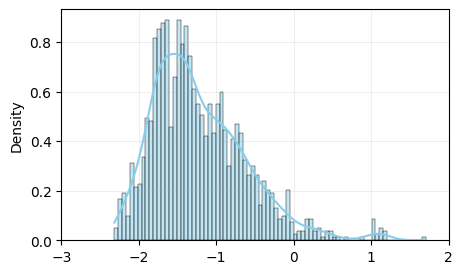

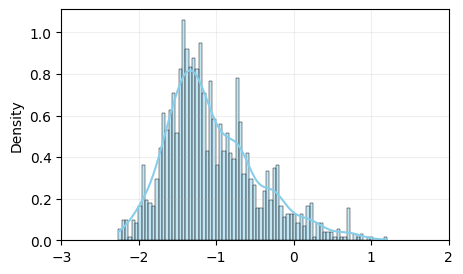

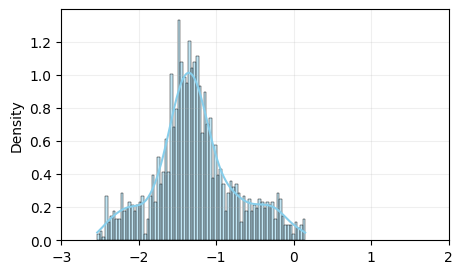

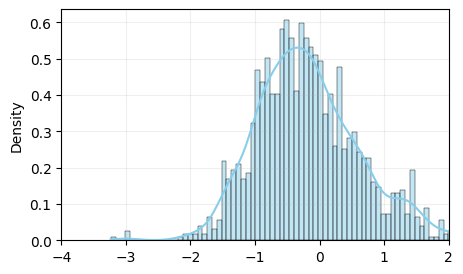

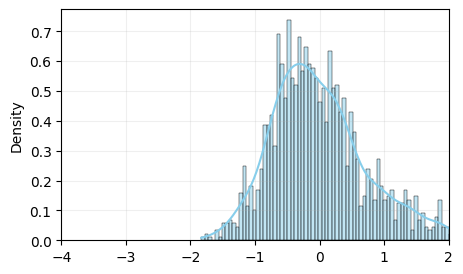

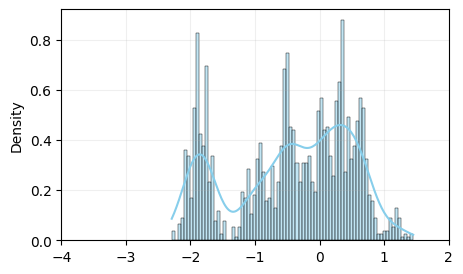

In [10]:
def visualize_samples(samples, figname, clip=[0, 1], logit_space=False):
    plt.figure(figsize=(5, 3))

    if logit_space:
        samples = logit(samples)
    sns.histplot(samples, bins=80, kde=True, stat="density", color='skyblue')

    plt.xlim(clip)

    plt.savefig(figname, format="pdf", bbox_inches="tight")
    plt.grid(alpha=0.2)
    plt.show()

_, ctr_logit_pred1, ctr_logit_sigma1, ctr_sigma_data1, _, cvr_logit_pred1, cvr_logit_sigma1, cvr_sigma_data1, cost1 = sample_campaign(campaign_id=CAMPAIGN_IDS_FILTERED[1], models_mode="all_features_0_3")
_, ctr_logit_pred2, ctr_logit_sigma2, ctr_sigma_data2, _, cvr_logit_pred2, cvr_logit_sigma2, cvr_sigma_data2, cost2 = sample_campaign(campaign_id=CAMPAIGN_IDS_FILTERED[1], models_mode="all_features_0_03")
_, ctr_logit_pred3, ctr_logit_sigma3, ctr_sigma_data3, _, cvr_logit_pred3, cvr_logit_sigma3, cvr_sigma_data3, cost3 = sample_campaign(campaign_id=CAMPAIGN_IDS_FILTERED[1], models_mode="all_features_0_001")

visualize_samples(ctr_logit_pred1, f"figs/env/ctr1_{len(ctr_sigma_data1)}samples.pdf", clip=[-3, 2])
visualize_samples(ctr_logit_pred2, f"figs/env/ctr2_{len(ctr_sigma_data2)}samples.pdf", clip=[-3, 2])
visualize_samples(ctr_logit_pred3, f"figs/env/ctr3_{len(ctr_sigma_data3)}samples.pdf", clip=[-3, 2])
visualize_samples(cvr_logit_pred1, f"figs/env/cvr1_{len(cvr_sigma_data1)}samples.pdf", clip=[-4, 2])
visualize_samples(cvr_logit_pred2, f"figs/env/cvr2_{len(cvr_sigma_data2)}samples.pdf", clip=[-4, 2])
visualize_samples(cvr_logit_pred3, f"figs/env/cvr3_{len(cvr_sigma_data3)}samples.pdf", clip=[-4, 2])


In [11]:
def simulate_offline_metrics(bids, clicks, conversions, wp, budget_proportion, target_cpc_proportion, mode="base", base_metrics=None):
    if mode == "base":
        campaign_total_cost = wp.sum()
        campaign_total_clicks = clicks.sum()
        campaign_total_conversions = np.sum(clicks * conversions)
        campaign_avg_cpc = campaign_total_cost / campaign_total_clicks

        budget = budget_proportion * campaign_total_cost
        target_cpc = target_cpc_proportion * campaign_avg_cpc

        is_win = bids >= wp
        total_conversions = np.sum(clicks * conversions * is_win)
        total_cost = np.sum(wp * is_win)
        total_clicks = np.sum(clicks * is_win)
        if total_clicks < 1:
            print("Base strategy achieves NO clicks!!")
            return None
        if total_conversions < 1:
            print("Base strategy achieves NO convs!!")
            return None
        avg_cpc = total_cost / total_clicks
        avg_cpc_proportion = avg_cpc / campaign_avg_cpc

        percent_exceeding_cpc = (avg_cpc - target_cpc) / target_cpc
        percent_exceeding_budget = (total_cost - budget) / budget

        return {
            "conversions": total_conversions,
            "clicks": total_clicks,
            "spent": total_cost,
            "avg_cpc": avg_cpc,
            "avg_cpc_proportion": avg_cpc_proportion,
            "conversions_uplift": 0.,
            "clicks_uplift": 0.,
            "spent_uplift": 0.,
            "percent_exceeding_cpc": percent_exceeding_cpc,
            "percent_exceeding_cpc_diff": 0.,
            "percent_exceeding_budget": percent_exceeding_budget,
            "percent_exceeding_budget_diff": 0.,
        }
    elif mode == "lift":
        assert base_metrics is not None

        campaign_total_cost = wp.sum()
        campaign_total_clicks = clicks.sum()
        campaign_total_conversions = np.sum(clicks * conversions)
        campaign_avg_cpc = campaign_total_cost / campaign_total_clicks

        budget = budget_proportion * campaign_total_cost
        target_cpc = target_cpc_proportion * campaign_avg_cpc

        base_conversions = base_metrics["conversions"]
        base_clicks = base_metrics["clicks"]
        base_spent = base_metrics["spent"]
        base_percent_exceeding_cpc = base_metrics["percent_exceeding_cpc"]
        base_percent_exceeding_budget = base_metrics["percent_exceeding_budget"]

        is_win = bids >= wp
        total_conversions = np.sum(clicks * conversions * is_win)
        total_cost = np.sum(wp * is_win)
        total_clicks = np.sum(clicks * is_win)
        if total_clicks < 1:
            print("Current strategy achieves NO clicks!!")
            return None
        avg_cpc = total_cost / total_clicks
        avg_cpc_proportion = avg_cpc / campaign_avg_cpc

        percent_exceeding_cpc = (avg_cpc - target_cpc) / target_cpc
        percent_exceeding_cpc_diff = percent_exceeding_cpc - base_percent_exceeding_cpc

        percent_exceeding_budget = (total_cost - budget) / budget
        percent_exceeding_budget_diff = percent_exceeding_budget - base_percent_exceeding_budget

        conversions_uplift = (total_conversions - base_conversions) / base_conversions
        clicks_uplift = (total_clicks - base_clicks) / base_clicks
        spent_uplift = (total_cost - base_spent) / base_spent

        return {
            "conversions": total_conversions,
            "clicks": total_clicks,
            "spent": total_cost,
            "avg_cpc": avg_cpc,
            "avg_cpc_proportion": avg_cpc_proportion,
            "conversions_uplift": conversions_uplift,
            "clicks_uplift": clicks_uplift,
            "spent_uplift": spent_uplift,
            "percent_exceeding_cpc": percent_exceeding_cpc,
            "percent_exceeding_cpc_diff": percent_exceeding_cpc_diff,
            "percent_exceeding_budget": percent_exceeding_budget,
            "percent_exceeding_budget_diff": percent_exceeding_budget_diff,
        }

## Experiment function

In [12]:
from experiment.non_robust_bid.offline_bidder import non_robust_bid
from experiment.denoise_bid.ctr_only.offline_bidder import denoise_bid as ctr_only_denoise_bid
from experiment.denoise_bid.joint.offline_bidder import denoise_bid as joint_denoise_bid
from experiment.robust_bid.offline_bidder import robust_bid

In [ ]:
def run_single_experiment(
    config,
    budget_proportion: float,
    target_cpc_proportion: float,
    bidder_mode: Literal["non-robust", "robust", "denoise", "denoise_ctr_only"] = "non-robust",
    models_mode = "ground_truth",
    campaign_id = CAMPAIGN_IDS_FILTERED[0],
    n_components = 1,
    base_metrics = None,
):
    click, ctr_logit_pred, ctr_logit_sigma, ctr_sigma_data, conversion, cvr_logit_pred, cvr_logit_sigma, cvr_sigma_data, cost = sample_campaign(campaign_id=campaign_id, models_mode=models_mode)

    budget = budget_proportion * cost.sum()
    target_cpc = target_cpc_proportion * cost.sum() / click.sum()

    if bidder_mode == "non-robust":
        bids = non_robust_bid(config.algorithms.non_robust_bid, ctr_logit_pred, cvr_logit_pred, cost, budget, target_cpc)

        metrics = simulate_offline_metrics(
            bids, click, conversion, cost, budget_proportion, target_cpc_proportion, mode="base",
        )
        if metrics is None:
            return None

    elif bidder_mode == "robust":
        bids = robust_bid(
            config.algorithms.robust_bid,
            ctr_logit_pred,
            cvr_logit_pred,
            ctr_logit_sigma,
            cvr_logit_sigma,
            cost,
            budget,
            target_cpc,
        )

        metrics = simulate_offline_metrics(
            bids, click, conversion, cost, budget_proportion, target_cpc_proportion, mode="lift", base_metrics=base_metrics,
        )
        if metrics is None:
            return None

    elif bidder_mode == "denoise":
        bids = joint_denoise_bid(
            config.algorithms.denoise_bid.joint,
            ctr_logit_pred,
            cvr_logit_pred,
            ctr_logit_sigma,
            cvr_logit_sigma,
            cost,
            budget,
            target_cpc,
            n_components=n_components,
        )

        metrics = simulate_offline_metrics(
            bids, click, conversion, cost, budget_proportion, target_cpc_proportion, mode="lift", base_metrics=base_metrics,
        )
        if metrics is None:
            return None
    
    elif bidder_mode == "denoise_ctr_only":
        bids = ctr_only_denoise_bid(
            config.algorithms.denoise_bid.ctr_only,
            ctr_logit_pred,
            ctr_logit_sigma,
            cvr_logit_pred,
            cvr_logit_sigma,
            cost,
            budget,
            target_cpc,
            n_components=n_components,
        )

        metrics = simulate_offline_metrics(
            bids, click, conversion, cost, budget_proportion, target_cpc_proportion, mode="lift", base_metrics=base_metrics,
        )
        if metrics is None:
            return None

    return {
        "models_mode": models_mode,
        "seed": config.common.seed,
        "metrics": metrics,
    }

### Experiment aggregating function

In [14]:
def aggregate_results(raw_path: str, summary_path: str):
    df = pd.read_csv(raw_path)

    grouped = (
        df.groupby("ctr/cvr_mode")
        .agg(
            conversions_uplift_mean=("conversions_uplift", "mean"),
            conversions_uplift_std=("conversions_uplift", "std"),
            conversions_uplift_se=("conversions_uplift", "sem"),
            clicks_uplift_mean=("clicks_uplift", "mean"),
            clicks_uplift_std=("clicks_uplift", "std"),
            clicks_uplift_se=("clicks_uplift", "sem"),
            spent_uplift_mean=("spent_uplift", "mean"),
            spent_uplift_std=("spent_uplift", "std"),
            spent_uplift_se=("spent_uplift", "sem"),
            percent_exceeding_cpc_mean=("percent_exceeding_cpc", "mean"),
            percent_exceeding_cpc_std=("percent_exceeding_cpc", "std"),
            percent_exceeding_cpc_se=("percent_exceeding_cpc", "sem"),
            percent_exceeding_cpc_diff_mean = ("percent_exceeding_cpc_diff", "mean"),
            percent_exceeding_cpc_diff_std = ("percent_exceeding_cpc_diff", "std"),
            percent_exceeding_cpc_diff_se = ("percent_exceeding_cpc_diff", "sem"),
            percent_exceeding_budget_mean=("percent_exceeding_budget", "mean"),
            percent_exceeding_budget_std=("percent_exceeding_budget", "std"),
            percent_exceeding_budget_se=("percent_exceeding_budget", "sem"),
            percent_exceeding_budget_diff_mean=("percent_exceeding_budget_diff", "mean"),
            percent_exceeding_budget_diff_std=("percent_exceeding_budget_diff", "std"),
            percent_exceeding_budget_diff_se=("percent_exceeding_budget_diff", "sem"),
        )
        .reset_index()
    )

    grouped.to_csv(summary_path, index=False)
    return summary_path

# Experiment

In [ ]:
BUDGET_PROPORTION = 0.2
TARGET_CPC_PROPORTION = 0.2

NUM_SEEDS = len(CAMPAIGN_IDS_FILTERED)
# NUM_SEEDS = 10  fast run for testing

IDS = CAMPAIGN_IDS_FILTERED[:NUM_SEEDS]
MODELS_MODES = [
    "all_features", 
    "all_features_0_3",
    "all_features_0_1",
    "all_features_0_03",
    "all_features_0_01",
    "all_features_0_003",
    "all_features_0_001",
]

In [ ]:
rows_non_robust = []
rows_robust = []

rows_normal = []
rows_gm_2_comp = []

rows_joint_normal = []
rows_joint_2_comp = []


for campaign_id in tqdm(IDS, total=NUM_SEEDS):
	for models_mode in MODELS_MODES:
		try:
			exp_res_non_robust = run_single_experiment(config, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="non-robust", models_mode=models_mode, campaign_id=campaign_id)
			if exp_res_non_robust is None:
				continue

			exp_res_robust = run_single_experiment(config, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="robust", models_mode=models_mode, campaign_id=campaign_id, base_metrics=exp_res_non_robust["metrics"])
			if exp_res_robust is None:
				continue

			exp_res_normal = run_single_experiment(config, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="denoise", n_components=1, models_mode=models_mode, campaign_id=campaign_id, base_metrics=exp_res_non_robust["metrics"])
			if exp_res_normal is None:
				continue

			exp_res_gm_2_comp = run_single_experiment(config, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="denoise", n_components=2, models_mode=models_mode, campaign_id=campaign_id, base_metrics=exp_res_non_robust["metrics"])
			if exp_res_gm_2_comp is None:
				continue

			exp_res_joint_normal = run_single_experiment(config, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="denoise_ctr_only", n_components=1, models_mode=models_mode, campaign_id=campaign_id, base_metrics=exp_res_non_robust["metrics"])
			if exp_res_joint_normal is None:
				continue

			exp_res_joint_2_comp = run_single_experiment(config, BUDGET_PROPORTION, TARGET_CPC_PROPORTION, bidder_mode="denoise_ctr_only", n_components=2, models_mode=models_mode, campaign_id=campaign_id, base_metrics=exp_res_non_robust["metrics"])
			if exp_res_joint_2_comp is None:
				continue

			rows_non_robust.append(
				{
					"SEED": config.common.seed,
					"ctr/cvr_mode": models_mode,
					"conversions": exp_res_non_robust["metrics"]["conversions"],
					"clicks": exp_res_non_robust["metrics"]["clicks"],
					"spent": exp_res_non_robust["metrics"]["spent"],
					"avg_cpc": exp_res_non_robust["metrics"]["avg_cpc"],
					"avg_cpc_proportion": exp_res_non_robust["metrics"]["avg_cpc_proportion"],
					"conversions_uplift": exp_res_non_robust["metrics"]["conversions_uplift"],
					"clicks_uplift": exp_res_non_robust["metrics"]["clicks_uplift"],
					"spent_uplift": exp_res_non_robust["metrics"]["spent_uplift"],
					"percent_exceeding_cpc": exp_res_non_robust["metrics"]["percent_exceeding_cpc"],
					"percent_exceeding_cpc_diff": exp_res_non_robust["metrics"]["percent_exceeding_cpc_diff"],
					"percent_exceeding_budget": exp_res_non_robust["metrics"]["percent_exceeding_budget"],
					"percent_exceeding_budget_diff": exp_res_non_robust["metrics"]["percent_exceeding_budget_diff"],
				}
			)


			rows_robust.append(
				{
					"SEED": config.common.seed,
					"ctr/cvr_mode": models_mode,
					"conversions": exp_res_robust["metrics"]["conversions"],
					"clicks": exp_res_robust["metrics"]["clicks"],
					"spent": exp_res_robust["metrics"]["spent"],
					"avg_cpc": exp_res_robust["metrics"]["avg_cpc"],
					"avg_cpc_proportion": exp_res_robust["metrics"]["avg_cpc_proportion"],
					"conversions_uplift": exp_res_robust["metrics"]["conversions_uplift"],
					"clicks_uplift": exp_res_robust["metrics"]["clicks_uplift"],
					"spent_uplift": exp_res_robust["metrics"]["spent_uplift"],
					"percent_exceeding_cpc": exp_res_robust["metrics"]["percent_exceeding_cpc"],
					"percent_exceeding_cpc_diff": exp_res_robust["metrics"]["percent_exceeding_cpc_diff"],
					"percent_exceeding_budget": exp_res_robust["metrics"]["percent_exceeding_budget"],
					"percent_exceeding_budget_diff": exp_res_robust["metrics"]["percent_exceeding_budget_diff"],
				}
			)


			rows_normal.append(
				{
					"SEED": config.common.seed,
					"ctr/cvr_mode": models_mode,
					"conversions": exp_res_normal["metrics"]["conversions"],
					"clicks": exp_res_normal["metrics"]["clicks"],
					"spent": exp_res_normal["metrics"]["spent"],
					"avg_cpc": exp_res_normal["metrics"]["avg_cpc"],
					"avg_cpc_proportion": exp_res_normal["metrics"]["avg_cpc_proportion"],
					"conversions_uplift": exp_res_normal["metrics"]["conversions_uplift"],
					"clicks_uplift": exp_res_normal["metrics"]["clicks_uplift"],
					"spent_uplift": exp_res_normal["metrics"]["spent_uplift"],
					"percent_exceeding_cpc": exp_res_normal["metrics"]["percent_exceeding_cpc"],
					"percent_exceeding_cpc_diff": exp_res_normal["metrics"]["percent_exceeding_cpc_diff"],
					"percent_exceeding_budget": exp_res_normal["metrics"]["percent_exceeding_budget"],
					"percent_exceeding_budget_diff": exp_res_normal["metrics"]["percent_exceeding_budget_diff"],
				}
			)


			rows_gm_2_comp.append(
				{
					"SEED": config.common.seed,
					"ctr/cvr_mode": models_mode,
					"conversions": exp_res_gm_2_comp["metrics"]["conversions"],
					"clicks": exp_res_gm_2_comp["metrics"]["clicks"],
					"spent": exp_res_gm_2_comp["metrics"]["spent"],
					"avg_cpc": exp_res_gm_2_comp["metrics"]["avg_cpc"],
					"avg_cpc_proportion": exp_res_gm_2_comp["metrics"]["avg_cpc_proportion"],
					"conversions_uplift": exp_res_gm_2_comp["metrics"]["conversions_uplift"],
					"clicks_uplift": exp_res_gm_2_comp["metrics"]["clicks_uplift"],
					"spent_uplift": exp_res_gm_2_comp["metrics"]["spent_uplift"],
					"percent_exceeding_cpc": exp_res_gm_2_comp["metrics"]["percent_exceeding_cpc"],
					"percent_exceeding_cpc_diff": exp_res_gm_2_comp["metrics"]["percent_exceeding_cpc_diff"],
					"percent_exceeding_budget": exp_res_gm_2_comp["metrics"]["percent_exceeding_budget"],
					"percent_exceeding_budget_diff": exp_res_gm_2_comp["metrics"]["percent_exceeding_budget_diff"],
				}
			)


			rows_joint_normal.append(
				{
					"SEED": config.common.seed,
					"ctr/cvr_mode": models_mode,
					"conversions": exp_res_joint_normal["metrics"]["conversions"],
					"clicks": exp_res_joint_normal["metrics"]["clicks"],
					"spent": exp_res_joint_normal["metrics"]["spent"],
					"avg_cpc": exp_res_joint_normal["metrics"]["avg_cpc"],
					"avg_cpc_proportion": exp_res_joint_normal["metrics"]["avg_cpc_proportion"],
					"conversions_uplift": exp_res_joint_normal["metrics"]["conversions_uplift"],
					"clicks_uplift": exp_res_joint_normal["metrics"]["clicks_uplift"],
					"spent_uplift": exp_res_joint_normal["metrics"]["spent_uplift"],
					"percent_exceeding_cpc": exp_res_joint_normal["metrics"]["percent_exceeding_cpc"],
					"percent_exceeding_cpc_diff": exp_res_joint_normal["metrics"]["percent_exceeding_cpc_diff"],
					"percent_exceeding_budget": exp_res_joint_normal["metrics"]["percent_exceeding_budget"],
					"percent_exceeding_budget_diff": exp_res_joint_normal["metrics"]["percent_exceeding_budget_diff"],
				}
			)


			rows_joint_2_comp.append(
				{
					"SEED": config.common.seed,
					"ctr/cvr_mode": models_mode,
					"conversions": exp_res_joint_2_comp["metrics"]["conversions"],
					"clicks": exp_res_joint_2_comp["metrics"]["clicks"],
					"spent": exp_res_joint_2_comp["metrics"]["spent"],
					"avg_cpc": exp_res_joint_2_comp["metrics"]["avg_cpc"],
					"avg_cpc_proportion": exp_res_joint_2_comp["metrics"]["avg_cpc_proportion"],
					"conversions_uplift": exp_res_joint_2_comp["metrics"]["conversions_uplift"],
					"clicks_uplift": exp_res_joint_2_comp["metrics"]["clicks_uplift"],
					"spent_uplift": exp_res_joint_2_comp["metrics"]["spent_uplift"],
					"percent_exceeding_cpc": exp_res_joint_2_comp["metrics"]["percent_exceeding_cpc"],
					"percent_exceeding_cpc_diff": exp_res_joint_2_comp["metrics"]["percent_exceeding_cpc_diff"],
					"percent_exceeding_budget": exp_res_joint_2_comp["metrics"]["percent_exceeding_budget"],
					"percent_exceeding_budget_diff": exp_res_joint_2_comp["metrics"]["percent_exceeding_budget_diff"],
				}
			)
		except Exception as e:
			print(f"mode: {models_mode}, exception: {e}")


df_non_robust = pd.DataFrame(rows_non_robust)
df_robust = pd.DataFrame(rows_robust)
df_normal = pd.DataFrame(rows_normal)
df_gm_2_comp = pd.DataFrame(rows_gm_2_comp)
df_joint_normal = pd.DataFrame(rows_joint_normal)
df_joint_2_comp = pd.DataFrame(rows_joint_2_comp)

non_robust_all_path = f"logs/non_robust_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
robust_all_path = f"logs/robust_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
normal_all_path = f"logs/normal_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
gm_2_comp_all_path = f"logs/gm_2_comp_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
joint_normal_all_path = f"logs/joint_normal_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"
joint_2_comp_all_path = f"logs/joint_2_comp_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}.csv"

df_non_robust.to_csv(non_robust_all_path, index=False)
df_robust.to_csv(robust_all_path, index=False)
df_normal.to_csv(normal_all_path, index=False)
df_gm_2_comp.to_csv(gm_2_comp_all_path, index=False)
df_joint_normal.to_csv(joint_normal_all_path, index=False)
df_joint_2_comp.to_csv(joint_2_comp_all_path, index=False)

In [28]:
non_robust_summary_path = f"logs/non_robust_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
robust_summary_path = f"logs/robust_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
normal_summary_path = f"logs/normal_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
gm_2_comp_summary_path = f"logs/gm_2_comp_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
joint_normal_summary_path = f"logs/joint_normal_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"
joint_2_comp_summary_path = f"logs/joint_2_comp_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv"

aggregate_results(non_robust_all_path, non_robust_summary_path)
aggregate_results(robust_all_path, robust_summary_path)
aggregate_results(normal_all_path, normal_summary_path)
aggregate_results(gm_2_comp_all_path, gm_2_comp_summary_path)
aggregate_results(joint_normal_all_path, joint_normal_summary_path)
aggregate_results(joint_2_comp_all_path, joint_2_comp_summary_path)

'logs/joint_2_comp_c0.2_b0.2_summary.csv'

In [29]:
BUDGET_PROPORTION = 0.2
TARGET_CPC_PROPORTION = 0.2

In [34]:
df_list_names = [
    f"logs/non_robust_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    # f"logs/robust_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    # f"logs/normal_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    # f"logs/gm_2_comp_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/joint_normal_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
    f"logs/joint_2_comp_c{TARGET_CPC_PROPORTION}_b{BUDGET_PROPORTION}_summary.csv",
]

exp_num = len(df_list_names)

name_fig = f"figs/exp/joint_dist_joint_corr_b{BUDGET_PROPORTION}_c{TARGET_CPC_PROPORTION}.pdf"

c_arr = [
    "non_robust",
    # "robust",
    # "normal",
    # "gm_2_comp",
    "joint_normal",
    "joint_2_comp",
]

In [38]:
metrics = [
    {
        "mean": "conversions_uplift_mean",
        "std": "conversions_uplift_se",
        "ylabel": "$(conv - conv_\\text{non_robust}) \\,/\\, conv_\\text{non_robust}$",
    },
    {
        "mean": "percent_exceeding_cpc_diff_mean",
        "std": "percent_exceeding_cpc_diff_se",
        "ylabel": "$(\\overline{CPC} - \\overline{CPC}_\\text{non_robust}) \\,/\\, С$",
    },
]

dfs = []
for name in df_list_names:
    dfs.append(pd.read_csv(name))

In [39]:
order = [
    "all_features",
    "all_features_0_3",
    "all_features_0_1",
    "all_features_0_03",
    "all_features_0_01",
    "all_features_0_003",
    "all_features_0_001",
]

In [ ]:
colors = plt.cm.tab20(np.linspace(0, 1, len(dfs)))

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    sharex=True,
    figsize=(7, 8),
    gridspec_kw=dict(hspace=0)
)

for ax, metric in zip(axes, metrics):

    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylabel(metric["ylabel"], fontsize=11)
    ax.tick_params(axis="both", which="major", labelsize=9, width=1.2, length=5)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

    for i, df in enumerate(dfs):
        if "ctr/cvr_mode_order" not in df.columns:
            df["ctr/cvr_mode_order"] = pd.Categorical(
                df["ctr/cvr_mode"],
                categories=order,
                ordered=True
            )
        df_sorted = df.sort_values("ctr/cvr_mode_order")

        x_labels = df_sorted["ctr/cvr_mode"].values
        x = np.arange(len(x_labels))

        y = df_sorted[metric["mean"]].values
        yerr = df_sorted[metric["std"]].values

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt='o-',
            capsize=4,
            linewidth=2,
            markersize=5,
            label=c_arr[i],
            color=colors[i],
        )

        for xi, yi, sei in zip(x, y, yerr):
            if sei == 0 or np.isnan(sei): 
                continue
            
            z_score = np.abs(yi / sei)
            stars = ""
            if z_score > 1.96:
                stars = "**"
            elif z_score > 1.645:
                stars = "*"
            
            if stars:
                if i == 2:
                    xy_offset, va, ha = (-2, 4), 'bottom', 'right'
                elif i == 1:
                    xy_offset, va, ha = (-2, -4), 'top', 'right'
                else:
                    xy_offset, va, ha = (2, 4), 'bottom', 'left'

                ax.annotate(
                    stars,
                    xy=(xi, yi),
                    xytext=xy_offset,
                    textcoords='offset points',
                    color=colors[i],
                    fontsize=10,
                    fontweight='bold',
                    ha=ha,
                    va=va
                )

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=90)

axes[1].legend(fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(name_fig, format="pdf", bbox_inches="tight")
plt.show()